Gradient Boosted Trees (XGBoost) uses hand-crafted lexical features — domain length, Shannon entropy (a measure of character randomness), vowel ratio, digit ratio, n-gram frequencies, and longest consonant run — as inputs. Shannon entropy is particularly diagnostic of DGA behavior, as algorithmically generated domains tend to have higher character-level entropy than human-readable ones. XGBoost builds an ensemble of decision trees sequentially, each correcting the residual errors of the previous, producing a strong classifier from many weak ones. This tests whether classical feature engineering can close the gap with neural methods while remaining highly deployment-efficient.


In [1]:
import pandas as pd
import numpy as np
import math
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from scipy.special import expit
import matplotlib.pyplot as plt
import time

In [2]:
dga_data = pd.read_csv("dga_data.csv")
dga_data.head()

,isDGA,domain,host,subclass
0,dga,6xzxsw3sokvg1tc752y1a6p0af,6xzxsw3sokvg1tc752y1a6p0af.com,gameoverdga
1,dga,glbtlxwwhbnpxs,glbtlxwwhbnpxs.ru,cryptolocker
2,dga,xxmamopyipbfpk,xxmamopyipbfpk.ru,cryptolocker
3,dga,zfd5szpi18i85wj9uy13l69rg,zfd5szpi18i85wj9uy13l69rg.net,newgoz
4,dga,jpqftymiuver,jpqftymiuver.ru,cryptolocker


Feature engineering

In [3]:
def domain_length(domain):
    return len(domain)

def shannon_entropy(domain):
    score = 0
    for char in set(domain):
        p = domain.count(char) /len(domain)
        score -= p * math.log2(p)
    return score

def vowel_ratio(domain):
    vowels = "aeiou"
    count = sum(1 for char in domain if char in vowels)
    return count / len(domain)

def digit_ratio(domain):
    digits = sum(1 for char in domain if char.isdigit())
    return digits / len(domain)

def longest_consonant_run(domain):
    vowels = "aeiou"
    max_run = 0
    run = 0

    for char in domain:
        if char.isalpha() and char not in vowels:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

def ngram_score(domain, n):
    unique_ngrams = set()

    for i in range(len(domain) - n + 1):
        ngram = domain[i:i + n]
        unique_ngrams.add(ngram)

    return len(unique_ngrams)

In [4]:
features = []

for domain in dga_data['domain']:
    domain = str(domain) # some domain are only numbers?
    features.append({
        "length": domain_length(domain),
        "entropy": shannon_entropy(domain),
        "vowel_ratio": vowel_ratio(domain),
        "digit_ratio": digit_ratio(domain),
        "longest_consonant_run": longest_consonant_run(domain),
        "2gram": ngram_score(domain, 2),
        "3gram": ngram_score(domain, 3),
        "4gram": ngram_score(domain, 4)
    })

X = pd.DataFrame(features)
y = dga_data["isDGA"] == "dga"

X.head()

X_train, X_test, y_train, y_test, family_train, family_test = train_test_split(
    X, y, dga_data['subclass'], test_size=0.2, random_state=26,
)

Training (baseline)

In [5]:
model = xgb.XGBClassifier(eval_metric='logloss', random_state=26)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob)

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
FPR: 0.03769 
Precision: 0.95716 
Recall: 0.83639 
F1-score: 0.89271 
AUC-ROC: 0.96428


Weighted BCE

In [6]:
weights = compute_sample_weight(class_weight={0: 5, 1: 1}, y=y_train)
model = xgb.XGBClassifier(eval_metric='logloss', random_state=26)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_search_w = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search_w.fit(X_train, y_train, **{'sample_weight': weights})
best_model_w = grid_search_w.best_estimator_

y_pred_w = best_model_w.predict(X_test)
y_pred_prob_w = best_model_w.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_w).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob_w)

print(f"Best Hyperparameters: {grid_search_w.best_params_}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
FPR: 0.00972 
Precision: 0.98778 
Recall: 0.78039 
F1-score: 0.87193 
AUC-ROC: 0.96430


Focal Loss

In [7]:
def focal_loss(alpha=0.25, gamma=2.0):
    def fl(y_true, y_pred):
        from scipy.special import expit
        p = expit(y_pred)
        grad = alpha * (y_true - p) * ((1 - p) ** gamma) + (1 - alpha) * ((0 - p) ** gamma) * (y_true - p)
        hess = alpha * ((1 - p) ** gamma) * p * (1 - p) + (1 - alpha) * (p ** gamma) * p * (1 - p)
        return -grad, hess
    return fl

model_fl = xgb.XGBClassifier(
    max_depth=10,
    learning_rate=0.1,
    n_estimators=100,
    objective=focal_loss(alpha=0.25, gamma=2.0),
    eval_metric='logloss',
    random_state=26
)

grid_search_fl = GridSearchCV(
    estimator=model_fl,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search_fl.fit(X_train, y_train)
best_model_fl = grid_search_fl.best_estimator_

y_pred_fl = best_model_fl.predict(X_test)
y_pred_prob_fl = best_model_fl.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_fl).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob_fl)

print(f"Best Hyperparameters: {grid_search_fl.best_params_}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
FPR: 0.03845 
Precision: 0.95641 
Recall: 0.83763 
F1-score: 0.89309 
AUC-ROC: 0.96420


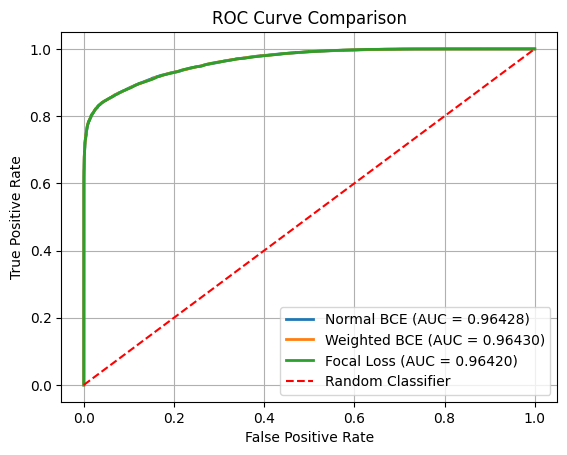

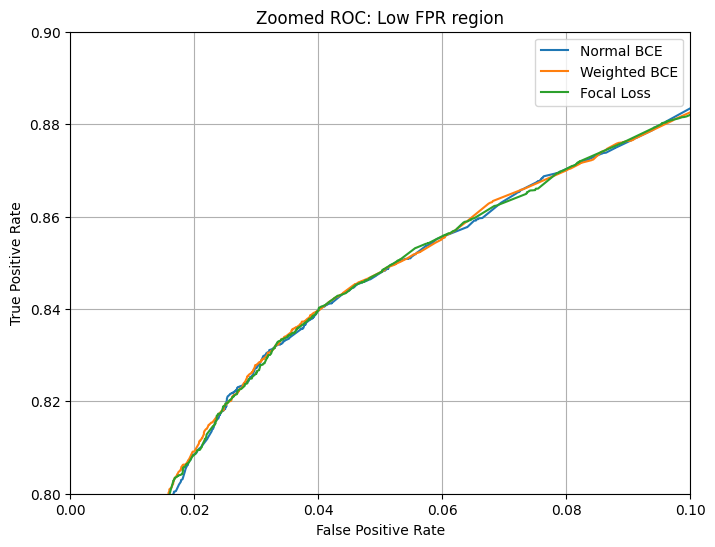

In [8]:
fpr_n, tpr_n, _ = roc_curve(y_test, y_pred_prob)
auc_n = auc(fpr_n, tpr_n)

fpr_w, tpr_w, _ = roc_curve(y_test, y_pred_prob_w)
auc_w = auc(fpr_w, tpr_w)

fpr_fl, tpr_fl, _ = roc_curve(y_test, y_pred_prob_fl)
auc_fl = auc(fpr_fl, tpr_fl)

plt.plot(fpr_n, tpr_n, lw=2, label=f'Normal BCE (AUC = {auc_n:.5f})')
plt.plot(fpr_w, tpr_w, lw=2, label=f'Weighted BCE (AUC = {auc_w:.5f})')
plt.plot(fpr_fl, tpr_fl, lw=2, label=f'Focal Loss (AUC = {auc_fl:.5f})')

plt.plot([0,1], [0,1], color='red', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

plt.figure(figsize=(8,6))
plt.plot(fpr_n, tpr_n, label='Normal BCE')
plt.plot(fpr_w, tpr_w, label='Weighted BCE')
plt.plot(fpr_fl, tpr_fl, label=f'Focal Loss')


plt.xlim(0, 0.1)
plt.ylim(0.8, 0.9)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Zoomed ROC: Low FPR region')
plt.legend()
plt.grid(True)
plt.show()

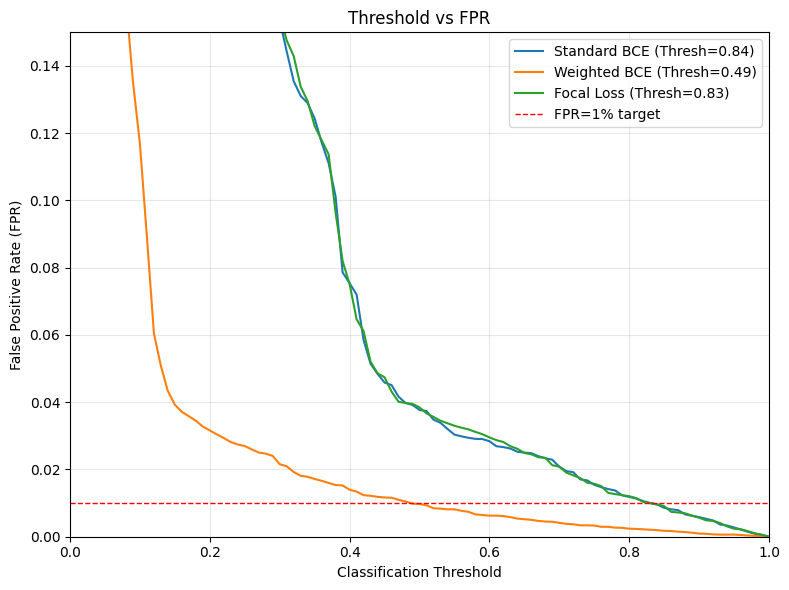

Model                 Threshold
--------------------------------
Standard BCE               0.84
Weighted BCE               0.49
Focal Loss                 0.83


In [ ]:
# Predictions to evaluate
preds = [
    ("Standard BCE", y_pred_prob),
    ("Weighted BCE", y_pred_prob_w),
    ("Focal Loss", y_pred_prob_fl)
]

thresholds = np.linspace(1, 0, 101)
target_fpr = 0.01

thresholds_chosen = {}

plt.figure(figsize=(8, 6))

for label, y_pred in preds:
    fprs = []
    selected_threshold = None
    for t in thresholds:
        y_pred_thresh = (y_pred > t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
        fpr = fp / (fp + tn)
        fprs.append(fpr)

        if fpr <= target_fpr:
            selected_threshold = t

    thresholds_chosen[label] = selected_threshold
    plt.plot(thresholds, fprs, label=f"{label} (Thresh={selected_threshold:.2f})")

plt.axhline(y=target_fpr, color='red', linestyle='--', linewidth=1, label=f'FPR={target_fpr*100:.0f}% target')

plt.xlabel("Classification Threshold")
plt.ylabel("False Positive Rate (FPR)")
plt.title("Threshold vs FPR")
plt.xlim(0, 1)
plt.ylim(0, 0.15)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"{'Model':<20} {'Threshold':>10}")
print("-" * 32)
for label, t in thresholds_chosen.items():
    print(f"{label:<20} {t:>10}")

Applying the chosen threshold

In [10]:
threshold =  thresholds_chosen["Standard BCE"]
y_pred = (y_pred_prob > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob)

print(f"Best Hyperparameters: {grid_search.best_params_}, threshold: {threshold}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}, threshold: 0.84
FPR: 0.00960 
Precision: 0.98790 
Recall: 0.77815 
F1-score: 0.87057 
AUC-ROC: 0.96428


In [11]:
threshold =  thresholds_chosen["Weighted BCE"]
y_pred_w = (y_pred_prob_w > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_w).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob_w)

print(f"Best Hyperparameters: {grid_search_w.best_params_}, threshold: {threshold}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}, threshold: 0.49
FPR: 0.00985 
Precision: 0.98764 
Recall: 0.78114 
F1-score: 0.87234 
AUC-ROC: 0.96430


In [12]:
threshold =  thresholds_chosen["Focal Loss"]
y_pred_fl = (y_pred_prob_fl > threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_fl).ravel()
fpr = fp / (fp + tn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * (precision * recall) / (precision + recall)
auc_roc = roc_auc_score(y_test, y_pred_prob_fl)

print(f"Hyperparameters: {grid_search_fl.best_params_}, threshold: {threshold}")
print(f"FPR: {fpr:.5f} \nPrecision: {precision:.5f} \nRecall: {recall:.5f} \nF1-score: {f1:.5f} \nAUC-ROC: {auc_roc:.5f}")

Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}, threshold: 0.83
FPR: 0.00997 
Precision: 0.98748 
Recall: 0.78077 
F1-score: 0.87204 
AUC-ROC: 0.96420


## XGBoost Summary

### Metrics at threshold = 0.5

| Loss Type     | Hyperparameters                                             | Threshold | FPR     | Precision | Recall  | F1-score | AUC-ROC |
|----------------|-------------------------------------------------------------|-----------|----------|------------|----------|-----------|----------|
| Standard BCE  | learning_rate: 0.1, max_depth: 10, n_estimators: 100        | 0.5       | 0.03769 | 0.95716   | 0.83639 | 0.89271  | 0.96428 |
| Weighted BCE  | learning_rate: 0.1, max_depth: 5, n_estimators: 200         | 0.5       | 0.00972 | 0.98778   | 0.78039 | 0.87193  | 0.96430 |
| Focal Loss    | learning_rate: 0.1, max_depth: 10, n_estimators: 100        | 0.5       | 0.03845 | 0.95641   | 0.83763 | 0.89309  | 0.96420 |

### Metrics at minimum threshold satisfying FPR < 1%

| Loss Type     | Hyperparameters                                             | Threshold | FPR     | Precision | Recall  | F1-score | AUC-ROC |
|----------------|-------------------------------------------------------------|-----------|----------|------------|----------|-----------|----------|
| Standard BCE  | learning_rate: 0.1, max_depth: 10, n_estimators: 100        | 0.84      | 0.00960 | 0.98790   | 0.77815 | 0.87057  | 0.96428 |
| Weighted BCE  | learning_rate: 0.1, max_depth: 5, n_estimators: 200         | 0.49      | 0.00985 | 0.98764   | 0.78114 | 0.87234  | 0.96430 |
| Focal Loss    | learning_rate: 0.2, max_depth: 5, n_estimators: 200        | 0.83      | 0.00997 | 0.98748   | 0.78077 | 0.87204  | 0.96420 |

## Latency

Standard (through xgb.XGBClassifier, slower)

In [13]:
latencies = []

for _, x in X.iterrows():
    x = x.values.reshape(1,-1)
    start = time.perf_counter()
    best_model.predict(x)
    end = time.perf_counter()
    latencies.append(end - start)

latencies_n = np.array(latencies)

average_latency = np.mean(latencies_n)
tail_95 = np.percentile(latencies_n, 95)
tail_99 = np.percentile(latencies_n, 99)

print(f"Average latency: {average_latency*1000:.3f} ms")
print(f"95th percentile latency: {tail_95*1000:.3f} ms")
print(f"99th percentile latency: {tail_99*1000:.3f} ms")

Average latency: 0.419 ms
95th percentile latency: 0.614 ms
99th percentile latency: 1.046 ms


Weighted

In [14]:
latencies = []

for _, x in X.iterrows():
    x = x.values.reshape(1,-1)
    start = time.perf_counter()
    best_model_w.predict(x)
    end = time.perf_counter()
    latencies.append(end - start)

latencies_w = np.array(latencies)

average_latency = np.mean(latencies_w)
tail_95 = np.percentile(latencies_w, 95)
tail_99 = np.percentile(latencies_w, 99)

print(f"Average latency: {average_latency*1000:.3f} ms")
print(f"95th percentile latency: {tail_95*1000:.3f} ms")
print(f"99th percentile latency: {tail_99*1000:.3f} ms")

Average latency: 0.412 ms
95th percentile latency: 0.601 ms
99th percentile latency: 0.972 ms


Focal Loss

In [15]:
latencies = []

for _, x in X.iterrows():
    x = x.values.reshape(1,-1)
    start = time.perf_counter()
    best_model_w.predict(x)
    end = time.perf_counter()
    latencies.append(end - start)

latencies_fl = np.array(latencies)

average_latency = np.mean(latencies_fl)
tail_95 = np.percentile(latencies_w, 95)
tail_99 = np.percentile(latencies_w, 99)

print(f"Average latency: {average_latency*1000:.3f} ms")
print(f"95th percentile latency: {tail_95*1000:.3f} ms")
print(f"99th percentile latency: {tail_99*1000:.3f} ms")

Average latency: 0.417 ms
95th percentile latency: 0.601 ms
99th percentile latency: 0.972 ms


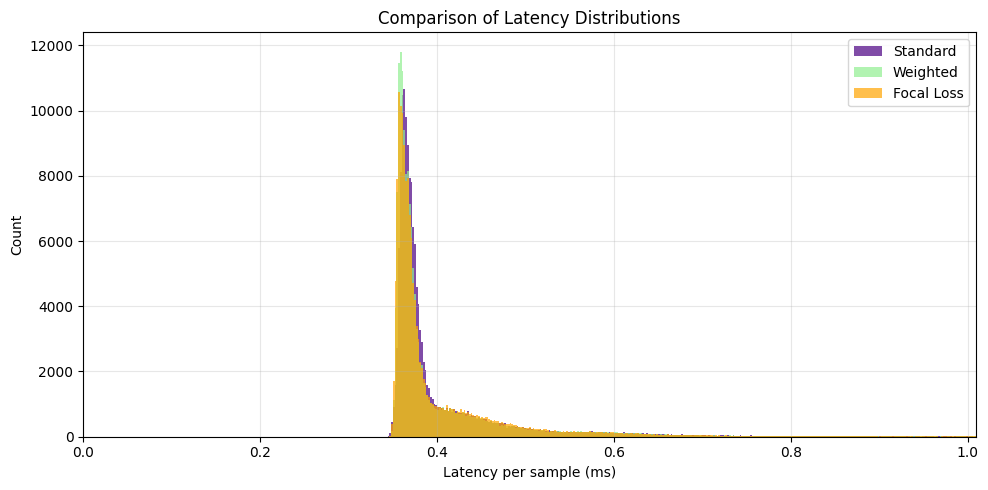

In [24]:
latency_dict = {
    'Standard': latencies_n,
    'Weighted': latencies_w,
    'Focal Loss': latencies_fl
}

colors = {
    'Standard': 'indigo',
    'Weighted': 'lightgreen',
    'Focal Loss': 'orange'
}

all_data_ms = np.concatenate([lat*1000 for lat in latency_dict.values()])
bin_width = 0.002
max_edge = np.percentile(all_data_ms, 99)
bins = np.arange(0, max_edge + bin_width, bin_width)

plt.figure(figsize=(10,5))
for name, lat_arr in latency_dict.items():
    plt.hist(lat_arr*1000, bins=bins, alpha=0.7, label=name, color=colors[name])

plt.xlabel('Latency per sample (ms)')
plt.ylabel('Count')
plt.title('Comparison of Latency Distributions')
plt.legend()
plt.xlim(0, max_edge)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Robustness Metrics

### Per family f1 variance

In [17]:
per_family = pd.DataFrame({
        'family': family_test,
        'predicted': [bool(y) for y in y_pred],
        'actual': y_test
        })

per_family = per_family[~per_family['family'].isin(['alexa', 'legit'])]
per_family.head()

,family,predicted,actual
18560,gameoverdga,True,True
78712,cryptolocker,True,True
56309,nivdort,False,True
3767,cryptolocker,True,True
46276,necurs,True,True


In [18]:
metrics_per_family = per_family.groupby('family').apply(
    lambda df: pd.Series({
        'f1': f1_score(df['actual'], df['predicted']),
        'precision': precision_score(df['actual'], df['predicted']),
        'recall': recall_score(df['actual'], df['predicted']),
    })
)
metrics_per_family

c:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ThanaponP\AppData\Local\Temp\ipykernel_11948\644226164.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  metrics_per_family = per_family.groupby('family').apply(


,f1,precision,recall
family,,,
bamital,1.000000,1.0,1.000000
cryptolocker,0.908721,1.0,0.832711
gameoverdga,1.000000,1.0,1.000000
goz,0.985288,1.0,0.971002
necurs,0.781273,1.0,0.641057
newgoz,1.000000,1.0,1.000000
nivdort,0.000000,0.0,0.000000


lexical indicators unable to identify majority of **nivdort** domain as DGA 

In [19]:
dga_data[dga_data['subclass']=='nivdort']
per_family[per_family['family']=='nivdort']

,family,predicted,actual
56309,nivdort,False,True
11597,nivdort,False,True
76119,nivdort,False,True
79682,nivdort,False,True
77157,nivdort,False,True
...,...,...,...
18803,nivdort,False,True
34750,nivdort,False,True
3139,nivdort,False,True
63560,nivdort,False,True


### LOFO

In [20]:
families = dga_data['subclass'].unique()

f1_seen = []
f1_heldout = []

for family in families:
    train_idx = dga_data['subclass'] != family
    test_idx = dga_data['subclass'] == family

    X_train_L, y_train_L = X[train_idx], y[train_idx]
    X_test_L, y_test_L = X[test_idx], y[test_idx]

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_L,
        y_train_L,
        test_size=0.2,
        random_state=26
    )

    model = xgb.XGBClassifier(random_state=26)
    model.fit(X_tr, y_tr)

    y_pred_val = model.predict(X_val)
    y_pred_test = model.predict(X_test_L)

    f1_val = f1_score(y_val, y_pred_val, average='macro')
    f1_test = f1_score(y_test_L, y_pred_test, average='macro')

    f1_seen.append(f1_val)
    f1_heldout.append(f1_test)

avg_f1_seen = np.mean(f1_seen)
avg_f1_heldout = np.mean(f1_heldout)
generalization_gap = avg_f1_seen - avg_f1_heldout

print("Average F1 on seen families (validation):", avg_f1_seen)
print("Average F1 on held-out families:", avg_f1_heldout)
print("LOFO Generalization Gap:", generalization_gap)

Average F1 on seen families (validation): 0.8979488856282304
Average F1 on held-out families: 0.40113473236159797
LOFO Generalization Gap: 0.4968141532666324


In [21]:
pd.DataFrame(f1_heldout, families)

,0
gameoverdga,0.499941
cryptolocker,0.422006
newgoz,0.499973
nivdort,0.004357
goz,0.467915
necurs,0.354386
bamital,0.444918
legit,0.444443
alexa,0.472274


poor generalization